In [ ]:
data = r"file.csv"

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
df = pd.read_csv(data,encoding = 'cp1252')

In [11]:
df.head(), df.tail()

(     customer name                                    customer e-mail  \
 0    Martina Avila  cubilia.Curae.Phasellus@quisaccumsanconvallis.edu   
 1    Harlan Barnes                                eu.dolor@diam.co.uk   
 2  Naomi Rodriquez  vulputate.mauris.sagittis@ametconsectetueradip...   
 3  Jade Cunningham                            malesuada@dignissim.com   
 4     Cedric Leach     felis.ullamcorper.viverra@egetmollislectus.net   
 
         country  gender        age  annual Salary  credit card debt  \
 0      Bulgaria       0  41.851720    62812.09301      11609.380910   
 1        Belize       0  40.870623    66646.89292       9572.957136   
 2       Algeria       1  43.152897    53798.55112      11160.355060   
 3  Cook Islands       1  58.271369    79370.03798      14426.164850   
 4        Brazil       1  57.313749    59729.15130       5358.712177   
 
      net worth  car purchase amount  
 0  238961.2505          35321.45877  
 1  530973.9078          45115.52566  
 2 

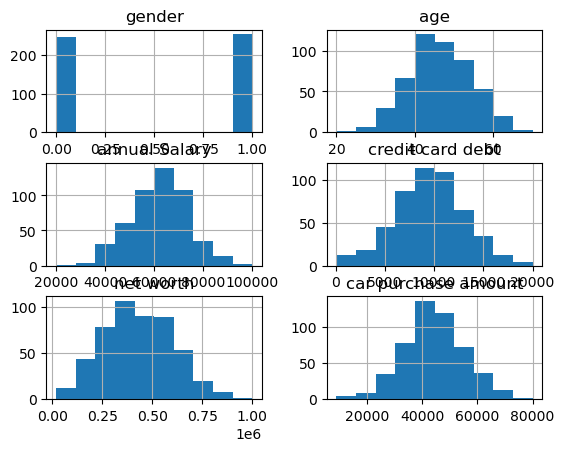

In [13]:
df.hist()
plt.show()

In [18]:
df.isnull().sum()

df.duplicated().sum()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer name        500 non-null    object 
 1   customer e-mail      500 non-null    object 
 2   country              500 non-null    object 
 3   gender               500 non-null    int64  
 4   age                  500 non-null    float64
 5   annual Salary        500 non-null    float64
 6   credit card debt     500 non-null    float64
 7   net worth            500 non-null    float64
 8   car purchase amount  500 non-null    float64
dtypes: float64(5), int64(1), object(3)
memory usage: 35.3+ KB


,gender,age,annual Salary,credit card debt,net worth,car purchase amount
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.506000,46.241674,62127.239608,9607.645049,431475.713625,44209.799218
std,0.500465,7.978862,11703.378228,3489.187973,173536.756340,10773.178744
min,0.000000,20.000000,20000.000000,100.000000,20000.000000,9000.000000
25%,0.000000,40.949969,54391.977195,7397.515792,299824.195900,37629.896040
50%,1.000000,46.049901,62915.497035,9655.035568,426750.120650,43997.783390
75%,1.000000,51.612263,70117.862005,11798.867487,557324.478725,51254.709517
max,1.000000,70.000000,100000.000000,20000.000000,1000000.000000,80000.000000


<Axes: >

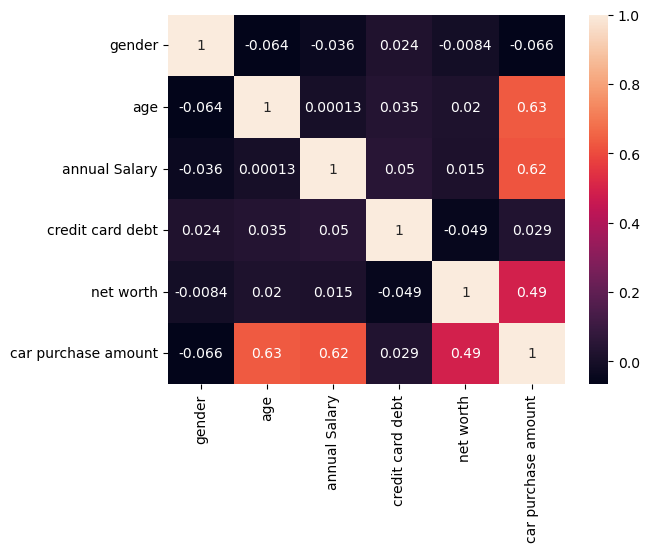

In [25]:
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True)

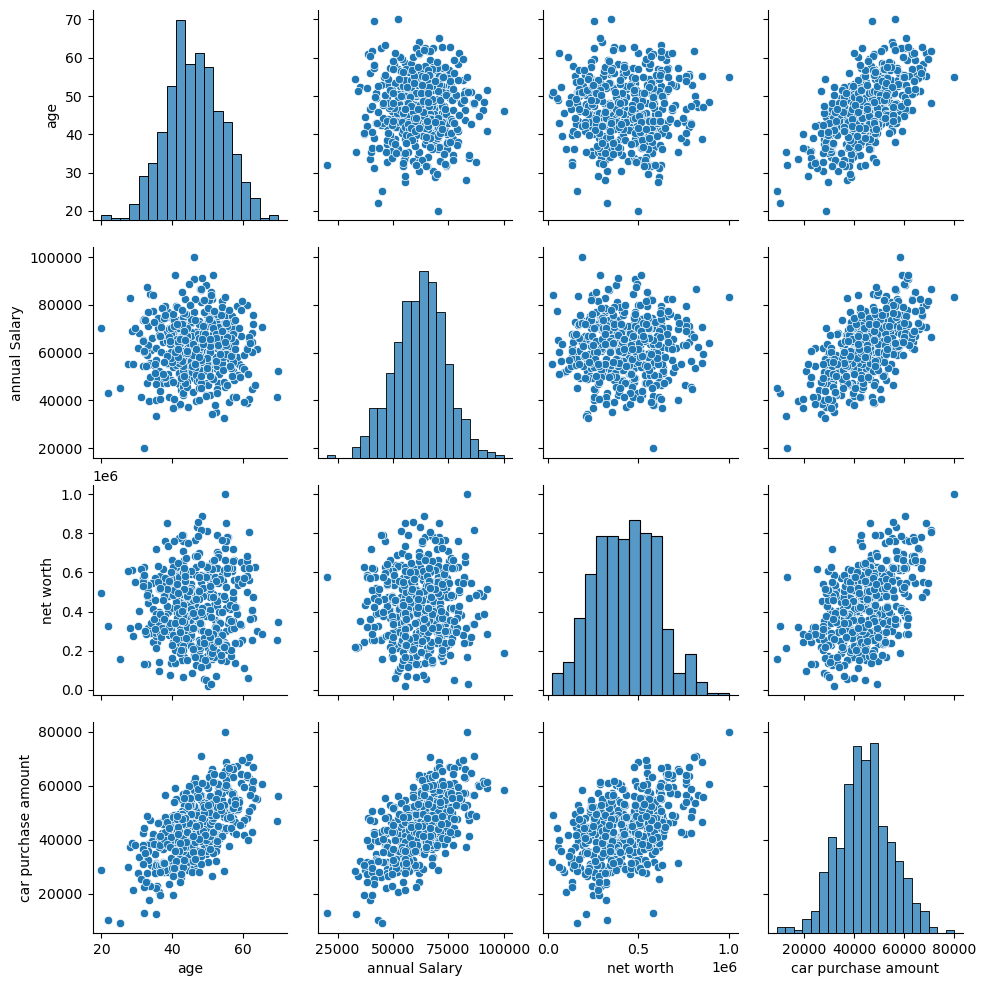

In [30]:
sns.pairplot(df[['age', 'annual Salary', 'net worth', 'car purchase amount']])
plt.show()

In [31]:
df.columns

Index(['customer name', 'customer e-mail', 'country', 'gender', 'age',
       'annual Salary', 'credit card debt', 'net worth',
       'car purchase amount'],
      dtype='object')

In [44]:
x = df.drop(columns=['car purchase amount','customer name','customer e-mail','country'])
y = df['car purchase amount']

In [ ]:
from sklearn.preprocessing import StandardScaler

Scaler = StandardScaler()
x_scale = Scaler.fit_transform(x)




array([[-1.01207287, -0.55074911,  0.05857619,  0.57427133, -1.11046945],
       [-1.01207287, -0.67383422,  0.38657041, -0.0099515 ,  0.57392937],
       [ 0.98807114, -0.38750768, -0.71236095,  0.4454518 ,  1.19397625],
       ...,
       [ 0.98807114,  0.96624515,  0.57832106,  0.28802326,  1.92114437],
       [ 0.98807114,  1.62075409, -1.05333541,  1.26384749, -0.54019026],
       [ 0.98807114,  0.06140832, -0.06470949, -0.06205457,  0.18153098]],
      shape=(500, 5))

In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.model_selection import train_test_split

In [60]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=.2)

In [61]:
model = LinearRegression()

model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
y_predict= model.predict(x_test)


mae = mean_absolute_error(y_test,y_predict)
mse = mean_squared_error(y_test,y_predict)
rmse = root_mean_squared_error(y_test,y_predict)

mae,mse,rmse



(1.1535708941181655, 2.094369602118626, 1.4471936988940444)

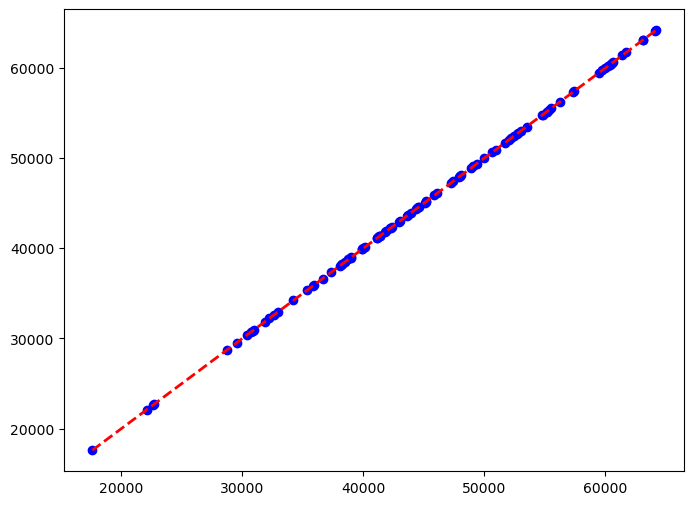

In [118]:
#actual vs prediction
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_predict, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

In [77]:
x.columns

Index(['gender', 'age', 'annual Salary', 'credit card debt', 'net worth'], dtype='object')

In [80]:
user_input = input('enter gender (0,1),age, annual salary, credit card debt, net worth')


In [85]:
parts = [i.strip()  for i in user_input.split(",")]

if len(parts)!=5:
    raise ValueError('Please enter exactly 5 values')

gender,age,salary,credit_car, net_worth = parts

In [106]:
gender = int(gender)
age = int(age)
salary = float(salary)
credit_car = float(credit_car)
net_worth = float(net_worth)
input_df = pd.DataFrame({'gender':[gender],
                         "age":[age],
                         "annual Salary":[salary],
                         "credit card debt":[credit_car],
                         "net worth":[net_worth]
                         })

In [113]:
scaled_input = Scaler.transform(input_df)
prediction = model.predict(scaled_input)
print(prediction)

[-43754.15270979]


c:\Users\selvam.anandhan\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [119]:
import pickle

pickle.dump(model,open('LinearRegression.pickle','wb'))